In [1]:
import datetime

import pandas as pd
import numpy as np
from scipy import stats
import scipy.stats as ss


from scipy.stats import shapiro, mannwhitneyu, norm
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

In [2]:
sns.set()
plt.style.use('ggplot')

# Задание 1. 

Представьте, что вы работаете в компании, которая разрабатывает мобильные игры. К вам пришел менеджер с рядом задач по исследованию нескольких аспектов мобильного приложения.

*Retention* – один из самых важных показателей в компании. Ваша задача – написать функцию, которая будет считать retention игроков по дням от даты регистрации игрока.

Загружаем данные

In [3]:
df_reg = pd.read_csv('/mnt/HC_Volume_18315164/home-jupyter/jupyter-j-postnova-20/project/problem1-reg_data.csv', sep=";")
df_auth = pd.read_csv('/mnt/HC_Volume_18315164/home-jupyter/jupyter-j-postnova-20/project/problem1-auth_data.csv', sep=";")

Смотрим, что из себя представляет каждый датафрейм

In [4]:
df_reg.head()

,reg_ts,uid
0,911382223,1
1,932683089,2
2,947802447,3
3,959523541,4
4,969103313,5


In [4]:
df_auth.head()

,auth_ts,uid
0,911382223,1
1,932683089,2
2,932921206,2
3,933393015,2
4,933875379,2


Смотрим на типы данных в датафреймах

In [5]:
df_reg.dtypes

reg_ts    int64
uid       int64
dtype: object

In [6]:
df_auth.dtypes

auth_ts    int64
uid        int64
dtype: object

Проврим есть ли пустые ячейки в данных

In [7]:
df_reg.isna().sum() 

reg_ts    0
uid       0
dtype: int64

In [8]:
df_auth.isna().sum() 

auth_ts    0
uid        0
dtype: int64

В функции для подсчета _Retention_ можно задать любой необходимый отрезок времени

In [5]:
def retention(df_reg, df_auth, start_date=None, end_date=None):
    # Приводим значения даты к нужному нам формату
    df_reg['reg_ts'] = pd.to_datetime(df_reg['reg_ts'], unit = 's').values.astype('datetime64[D]')
    df_auth['auth_ts'] = pd.to_datetime(df_auth['auth_ts'], unit = 's').values.astype('datetime64[D]')

    # Зададаем период, за которй хотим провести анализ
    df_reg = df_reg.query('reg_ts >= @start_date')
    df_auth = df_auth.query('auth_ts <= @end_date') 
    
    # Объединяем датафреймы по id пользователей и добавляем столбец - количество дней со дня регистрации
    df = df_reg.merge(df_auth, on='uid')
    df['days'] = (df.auth_ts - df.reg_ts).dt.days
        
    # Считаем когорты и собираем таблицу, чтобы посмотреть количество новых пользователей после регистрации, а далее получим retention 
    cohort = (
        df.groupby(['reg_ts','days'], as_index=False)
          .agg({'uid':'nunique'})
          .pivot(index='reg_ts', columns='days', values='uid')
    )
    retention_table = cohort.div(cohort[0], axis=0)
    
    # Дадим настройки таблицы для наглядности

    plt.figure(figsize=(20, 8))
    plt.title('Retention')
    sns.heatmap(data = retention_table, annot=True, vmin=0, vmax=0.12, fmt='.1%', cmap='crest')
    plt.show()


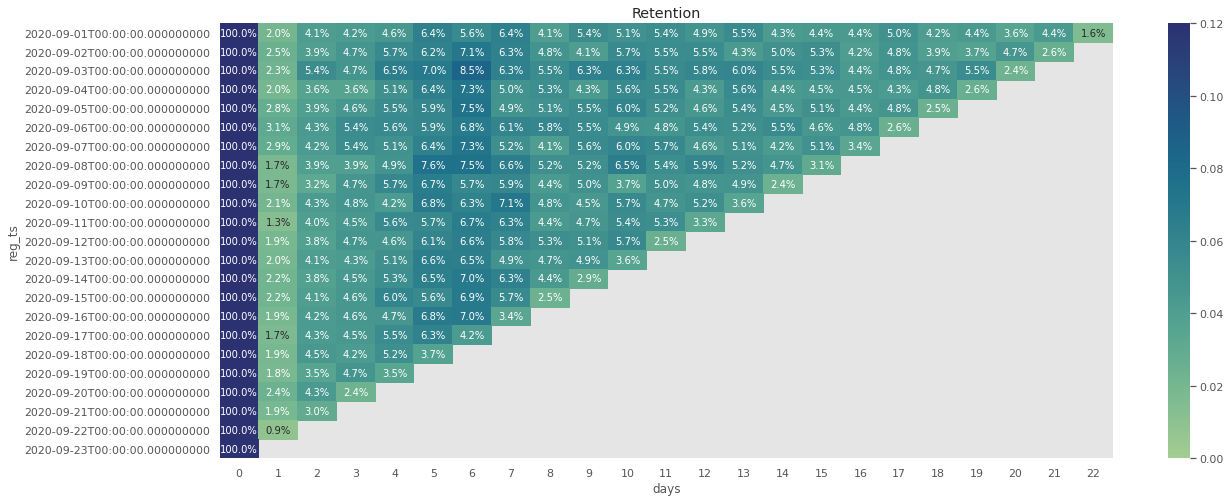

In [6]:
retention(df_reg, df_auth, start_date = datetime.date(2020, 9, 1), end_date = datetime.date(2020, 9, 23)) 

# Задание 2. 

Имеются результаты A/B теста, в котором двум группам пользователей предлагались различные наборы акционных предложений. Известно, что *ARPU* в тестовой группе выше на 5%, чем в контрольной. При этом в контрольной группе 1928 игроков из 202103 оказались платящими, а в тестовой – 1805 из 202667.

- Какой набор предложений можно считать лучшим? 
- Какие метрики стоит проанализировать для принятия правильного решения и как?

Подгружаем данные и посмотрим как они выглядят 

In [3]:
df_2 = pd.read_csv('/mnt/HC_Volume_18315164/home-jupyter/jupyter-j-postnova-20/project/Проект_1_Задание_2.csv', sep=";")
df_2.head()

,user_id,revenue,testgroup
0,1,0,b
1,2,0,a
2,3,0,a
3,4,0,b
4,5,0,b


Посчитаем количествово уникальных user_id, посмотрим данные на наличие пропусков, проверим типы данных, а так же посмотрим на размер датафрейма

In [4]:
df_2.nunique()

user_id      404770
revenue        1477
testgroup         2
dtype: int64

In [5]:
df_2.isna().sum() 

user_id      0
revenue      0
testgroup    0
dtype: int64

In [6]:
df_2.dtypes 

user_id       int64
revenue       int64
testgroup    object
dtype: object

In [7]:
df_2.shape

(404770, 3)

Пропуски в данных отсутствуют.

Данные в столбцах приводить к друому типу не требуется.
Пользователи в данных у нас уникальные (user_id не повторяются)

Посмотрим на описательную статистику выручки.

In [8]:
df_2.revenue.describe() 

count    404770.000000
mean         26.083435
std         681.652928
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       37433.000000
Name: revenue, dtype: float64

Посмотрим на распределение данных, тут видим, что в тестовой группе А есть значительные выбросы

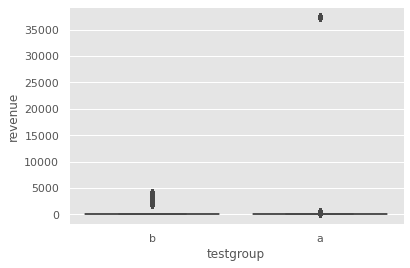

In [9]:
sns.boxplot(x = 'testgroup', y = 'revenue', data = df_2);

Метрики для оценки эксперемента выберем такие: ARPU, ARPPU и CR (конверсия пользователей в платящие). Так как большинство пользователей в выборках не платящие, то при проведении А/В тестов на полной выборке результаты могут быть искажены.Таким образом, за ключевые метрики возьмем ARPU, ARPPU и конверсию в плательщиков(CR). 



Разделяем данные на тестовую и контрольную группы

In [10]:
control = df_2.query('testgroup == "a"')
test = df_2.query('testgroup == "b"')

Визуализируем наши группы, чтобы посмотреть как распределились платежи наших пользователей в контрольной и тестовой группах.

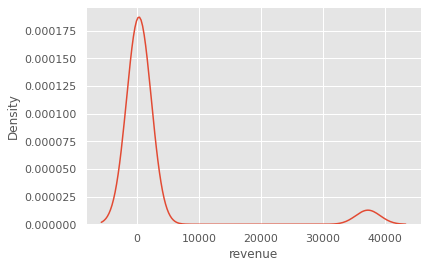

In [11]:
sns.kdeplot(control.query('revenue != 0').revenue); 

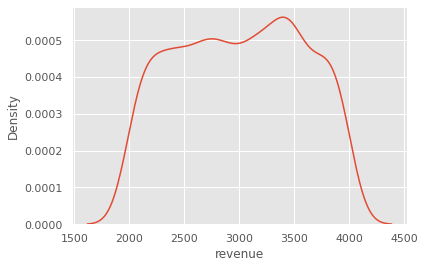

In [13]:
sns.kdeplot(test.query('revenue != 0').revenue); 

Cчитаем ARPU - средний доход с привлечённого пользователя. ARPU в тестовой группе выше на 5.3%, чем в контрольной.

In [12]:
ARPU_control = control['revenue'].sum() / control['user_id'].count()
ARPU_test = test['revenue'].sum() / test['user_id'].count()

print(f"ARPU контрольной группы: {ARPU_control}, ARPU тестовой группы: {ARPU_test}")

ARPU контрольной группы: 25.413719736965806, ARPU тестовой группы: 26.75128659327863


In [13]:
round((ARPU_test - ARPU_control) / ARPU_control * 100, 1)

5.3

Cчитаем ARPPU - cредний доход на платящего пользователя. ARPPU в тестовой группе выше на 12.7%, чем в контрольной.

In [14]:
ARPPU_control = control.query('revenue != 0').revenue.sum()/control.query('revenue != 0').revenue.count()
ARPPU_test = test.query('revenue != 0').revenue.sum()/test.query('revenue != 0').revenue.count()

print(f"ARPPU контрольной группы: {ARPPU_control}, ARPPU тестовой группы: {ARPPU_test}")

ARPPU контрольной группы: 2663.9984439834025, ARPPU тестовой группы: 3003.6581717451522


In [15]:
round((ARPPU_test - ARPPU_control) / ARPPU_control * 100, 1)

12.7

Считаем CR в покупку. CR в покупку в тестовой группе снизилась на 6.6%

In [16]:
CR_control = control.query('revenue != 0').user_id.count() / control.user_id.count()
CR_test = test.query('revenue != 0').user_id.count()    / test.user_id.count()

print(f"конверсия в контрольной группе: {CR_control}, конверсия в тестовой группе: {CR_test}")

конверсия в контрольной группе: 0.009539690157988749, конверсия в тестовой группе: 0.008906235351586593


In [17]:
round((CR_test - CR_control) / CR_control * 100, 1)

-6.6

При оценки различий, мы можем использовть разные статистические тесты: t-test (для его использования нужно проверить на гомогенность дисперсий и нормальность распределения среднего), критерий Манна - Уитни (в нашем случае он не пожходит, так как мы не знаем природу выбросов) и Бутстрап - анализ.

In [23]:
stats.levene(control.revenue, test.revenue, center='mean')

LeveneResult(statistic=1.57736044973474, pvalue=0.2091420343022563)

Мы не можем отклонить гипотезу о гомогенности дисперсий, так как  pvalue > 0.05

Приверим распределена ли величина выручки по нормальному закону при помощи теста Шапиро-Уилка.

In [45]:
print(shapiro(control.revenue.sample(1000)))
print(shapiro(test.revenue.sample(1000)))

ShapiroResult(statistic=0.08748036623001099, pvalue=0.0)
ShapiroResult(statistic=0.060822904109954834, pvalue=0.0)


В результате, мы отклоняем гипотезу о нормальности распределения средних, так как pvalue < 0.05 
Будем использовать Бутстрап - анализа, так как условия для t-test оказались не оптимальными.

In [47]:
def get_bootstrap(
    data_column_1, # числовые значения первой выборки
    data_column_2, # числовые значения второй выборки
    boot_it = 1000, # количество бутстрэп-подвыборок
    statistic = np.mean, # интересующая нас статистика
    bootstrap_conf_level = 0.95 # уровень значимости
):
    boot_data = []
    for i in tqdm(range(boot_it)): # извлекаем подвыборки
        samples_1 = data_column_1.sample(
            len(data_column_1), 
            replace = True # параметр возвращения
        ).values
        
        samples_2 = data_column_2.sample(
            len(data_column_1), 
            replace = True
        ).values
        
        boot_data.append(statistic(samples_1)-statistic(samples_2)) # mean() - применяем статистику
        
    pd_boot_data = pd.DataFrame(boot_data)
        
    left_quant = (1 - bootstrap_conf_level)/2
    right_quant = 1 - (1 - bootstrap_conf_level) / 2
    quants = pd_boot_data.quantile([left_quant, right_quant])
        
    p_1 = norm.cdf(
        x = 0, 
        loc = np.mean(boot_data), 
        scale = np.std(boot_data)
    )
    p_2 = norm.cdf(
        x = 0, 
        loc = -np.mean(boot_data), 
        scale = np.std(boot_data)
    )
    p_value = min(p_1, p_2) * 2
        
    # Визуализация
    _, _, bars = plt.hist(pd_boot_data[0], bins = 50)
    for bar in bars:
        if bar.get_x() <= quants.iloc[0][0] or bar.get_x() >= quants.iloc[1][0]:
            bar.set_facecolor('red')
        else: 
            bar.set_facecolor('grey')
            bar.set_edgecolor('black')
    
    plt.style.use('ggplot')
    plt.vlines(quants,ymin=0,ymax=50,linestyle='--')
    plt.xlabel('boot_data')
    plt.ylabel('frequency')
    plt.title("Histogram of boot_data")
    plt.show()
       
    return {"boot_data": boot_data, 
            "quants": quants, 
            "p_value": p_value}

Строим эмпирическое распределение параметра, смотрим на значение p_value.
Применяем бутстрап для метрики ARPU


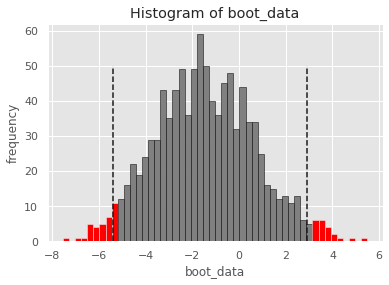

In [48]:
boot_data = get_bootstrap(control.revenue, test.revenue);

In [49]:
boot_data["p_value"] 

0.49255674507579816

Применяем бутстрап для метрики ARPPU. 

Подготовим для этого данные

In [50]:
control_users = control.query('revenue != 0')
test_users = test.query('revenue != 0')

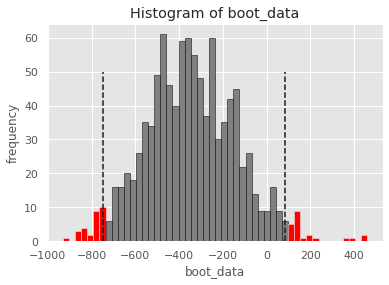

In [51]:
boot_data_users = get_bootstrap(control_users.revenue, test_users.revenue);

In [52]:
boot_data_users["p_value"] 

0.09784358593077512

Проверим конверсию (CR) - не является ли эта разница случайной, с помощью теста для категориальных переменных.

In [54]:
df_2['paying_user'] = df_2.revenue > 0

In [55]:
stats.chi2_contingency(pd.crosstab(df_2.paying_user, df_2.testgroup))

(4.374729521260405,
 0.03647561892312613,
 1,
 array([[200239.10075104, 200797.89924896],
        [  1863.89924896,   1869.10075104]]))

При проверке конверсии, мы узнали, что  pvalue < 0.05, а значит можем принять альтернативную гипотезу: показатель конверсии в контрольной группе значимо отличается от показателя в тестовой

## Вывод
- ARPU и ARPPU в контрольной группе меньше, чем в тестовой группе;
- Распределения выручки тестовой и контрольной группы сильно отличаются. Контрольная группа имеет большие выбросы;
- CR в тестовой группе меньше, чем в контрольной;
- Статистический метод Бутстрап-анализа, при сравнении метрики ARPU, ARPPU между группами, показывает отсутствие значимых различий (p-value > 0.05); 
- При сравнении конверсии между группами, мы можем заметить, что конверсия в покупку в контрольной группе значимо отличается от показателя в тестовой;

Исходя из всего вышеперечисленного, тестовое предложение лучше, однако, рекомендуется вернуться к контрольному варианту и принять H0. 

Если же использовать тестовое предложение, то нужно учесть все риски, провести А/А тест, для исключения ошибок в выборе групп для эксперимента,а также провести повторный А/В тест.

# Задание 3. 

В игре Plants & Gardens каждый месяц проводятся тематические события, ограниченные по времени. В них игроки могут получить уникальные предметы для сада и персонажей, дополнительные монеты или бонусы. Для получения награды требуется пройти ряд уровней за определенное время. С помощью каких метрик можно оценить результаты последнего прошедшего события?


Метрики для оценки результатов 

Экономические метрики, которые показывают как польщоватали платят и их вовлеченность:
1. Revenue - доход;
2. ARPPU, ARPU - средний доход на платяльщего пользователя, средний доход с привлечённого пользователя;

Метрики лояльности и маркетинга, показывают динамику аудитории и ее вовлеченность
1. New & lost users - новые и потерянные пользователи;
2. DAU - показывает число уникальных пользователей, вошедших в игру в течение дня;
3. WAU - показывает число уникальных пользователей, вошедших в игру в течение недели;
4. MAU - показывает число уникальных пользователей, вошедших в игру в течение месяца;
5. CR - конверсия в покупку;
6. Retention n-го дня - удержание пользователя;
7. LTV - время жизни пользователя;

Предположим, в другом событии мы усложнили механику событий так, что при каждой неудачной попытке выполнения уровня игрок будет откатываться на несколько уровней назад. Изменится ли набор метрик оценки результата? Если да, то как?

При усложнении механики  в новом событии можно использовать такой же набор метрик, но так же отслеживать еще такие:
    
1. Churn Rate - метрика, обратная retention, показывает оттток пользователей;
2. ASL - продолжительность сессии;
3. Воронка, чтобы отследить где именно отваливаются игроки;
4. Количество удалений(после запуска ивента);